# 01 - Exploration et Compréhension des Données

## Objectifs de ce notebook
- Charger et comprendre le dataset Titanic
- Explorer la structure des données
- Identifier les valeurs manquantes
- Comprendre chaque variable

In [10]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Seed pour reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Chargement des données

Le dataset provient de [Kaggle Titanic Competition](https://www.kaggle.com/competitions/titanic).

Pour télécharger les données :
1. Aller sur la page Kaggle
2. Télécharger `train.csv` et `test.csv`
3. Les placer dans `data/raw/`

In [11]:
# Charger les données
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

print(f"Taille du dataset d'entraînement : {train_df.shape}")
print(f"Taille du dataset de test : {test_df.shape}")

Taille du dataset d'entraînement : (891, 12)
Taille du dataset de test : (418, 11)


## 2. Aperçu des données

In [12]:
# Premières lignes
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [13]:
# Dernières lignes
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [14]:
# Échantillon aléatoire
train_df.sample(5, random_state=RANDOM_STATE)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


## 3. Description des variables

| Variable | Définition | Type | Valeurs |
|----------|------------|------|----------|
| PassengerId | Identifiant unique | int | - |
| Survived | **Variable cible** (survie) | int | 0 = Non, 1 = Oui |
| Pclass | Classe du billet | int | 1 = 1ère, 2 = 2ème, 3 = 3ème |
| Name | Nom du passager | str | - |
| Sex | Sexe | str | male, female |
| Age | Âge en années | float | - |
| SibSp | Nombre de frères/sœurs/conjoints à bord | int | - |
| Parch | Nombre de parents/enfants à bord | int | - |
| Ticket | Numéro du billet | str | - |
| Fare | Prix du billet | float | - |
| Cabin | Numéro de cabine | str | - |
| Embarked | Port d'embarquement | str | C = Cherbourg, Q = Queenstown, S = Southampton |

In [15]:
# Types de données
print("Types de données :")
print(train_df.dtypes)

Types de données :
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [16]:
# Informations générales
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 4. Statistiques descriptives

In [17]:
# Variables numériques
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
# Variables catégorielles
train_df.describe(include=['object'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


## 5. Analyse des valeurs manquantes

In [25]:
# Compter les valeurs manquantes
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Valeurs manquantes', ascending=False)

print("Valeurs manquantes par colonne :")
missing_df[missing_df['Valeurs manquantes'] > 0]

Valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage (%)
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


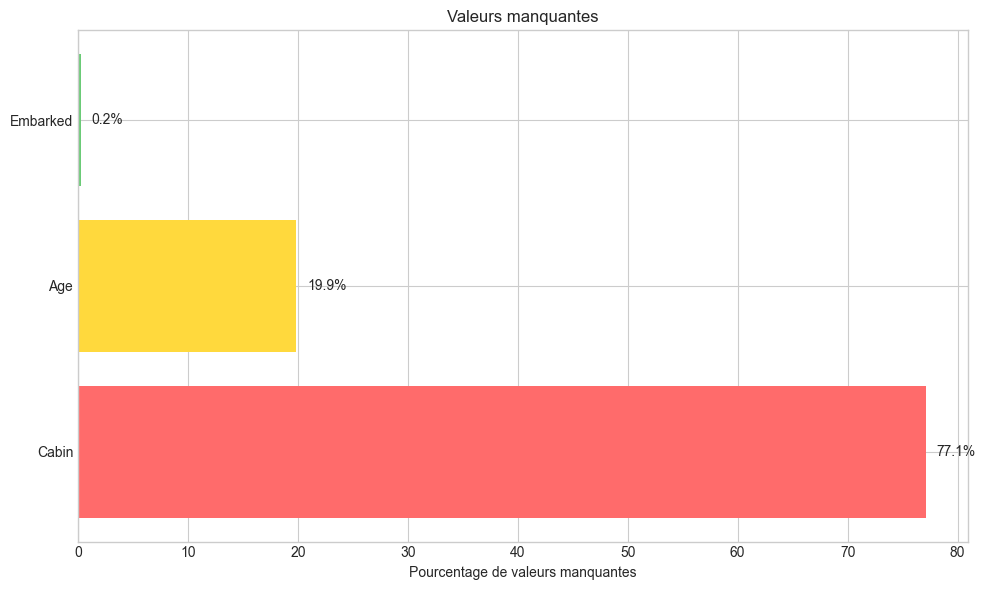

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

missing_cols = missing_df[missing_df['Valeurs manquantes'] > 0]
colors = ['#ff6b6b' if pct > 50 else '#ffd93d' if pct > 10 else '#6bcb77' 
          for pct in missing_cols['Pourcentage (%)']]

bars = ax.barh(missing_cols.index, missing_cols['Pourcentage (%)'], color=colors)
ax.set_xlabel('Pourcentage de valeurs manquantes')
ax.set_title('Valeurs manquantes')

for bar, pct in zip(bars, missing_cols['Pourcentage (%)']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', va='center')

plt.tight_layout()
plt.show()

## 6. Analyse de la variable cible (Survived)

In [30]:
survived_counts = train_df['Survived'].value_counts()
survived_pct = train_df['Survived'].value_counts(normalize=True) * 100

print("Distribution de Survived :")
print(f"  - Décédés (0) : {survived_counts[0]} ({survived_pct[0]:.1f}%)")
print(f"  - Survivants (1) : {survived_counts[1]} ({survived_pct[1]:.1f}%)")

Distribution de Survived :
  - Décédés (0) : 549 (61.6%)
  - Survivants (1) : 342 (38.4%)


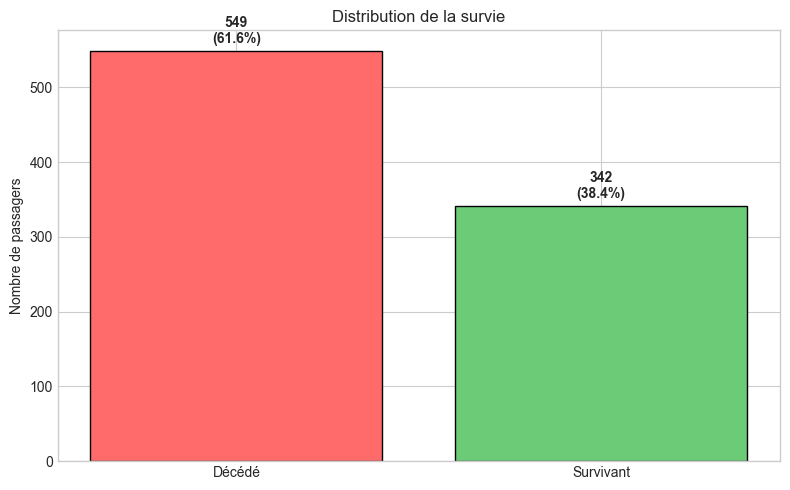

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#ff6b6b', '#6bcb77']
labels = ['Décédé', 'Survivant']

bars = ax.bar(labels, survived_counts.values, color=colors, edgecolor='black')
ax.set_ylabel('Nombre de passagers')
ax.set_title('Distribution de la survie')

for bar, count, pct in zip(bars, survived_counts.values, survived_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Valeurs uniques par colonne

In [32]:
for col in train_df.columns:
    n_unique = train_df[col].nunique()
    print(f"{col}: {n_unique} valeurs uniques")
    
    if n_unique <= 10:
        print(f"   → {train_df[col].unique()}")

PassengerId: 891 valeurs uniques
Survived: 2 valeurs uniques
   → [0 1]
Pclass: 3 valeurs uniques
   → [3 1 2]
Name: 891 valeurs uniques
Sex: 2 valeurs uniques
   → ['male' 'female']
Age: 88 valeurs uniques
SibSp: 7 valeurs uniques
   → [1 0 3 4 2 5 8]
Parch: 7 valeurs uniques
   → [0 1 2 5 3 4 6]
Ticket: 681 valeurs uniques
Fare: 248 valeurs uniques
Cabin: 147 valeurs uniques
Embarked: 3 valeurs uniques
   → ['S' 'C' 'Q' nan]
